In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
})

# ClassTran demand-segment flexibility analysis

This notebook now centers on the new flexibility concept:

```text
demand segment = purpose + 1-mile origin grid zone + weekday
```

The goal is to study whether each type of demand has observed time and destination alternatives in the original Ecolane trip data, then relate those segment-level flexibility patterns to completion, cancellation, and demand-management opportunities.

In [2]:
from pathlib import Path

DATA_PATH = Path(
    "/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/"
    "Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx"
)
SHEET_NAME = "SMART Trip Data"
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)


def combine_address_parts(df, street_number_col, street_col, city_col, state_col, zipcode_col):
    parts = []
    for col in [street_number_col, street_col, city_col, state_col, zipcode_col]:
        part = df[col].fillna('').astype(str).str.strip()
        part = part.str.replace(r'\.0$', '', regex=True)
        parts.append(part)
    address = parts[0] + ' ' + parts[1]
    address = address.str.strip()
    city_state_zip = parts[2] + ', ' + parts[3] + ' ' + parts[4]
    city_state_zip = city_state_zip.str.replace(r'^[,\s]+|[,\s]+$', '', regex=True)
    return (address + ', ' + city_state_zip).str.replace(r'^[,\s]+|[,\s]+$', '', regex=True)


# Standardized aliases used by later cells.
df_raw['pickup_lat'] = df_raw['Pick-up Latitude']
df_raw['pickup_lon'] = df_raw['Pick-up Longitude']
df_raw['dropoff_lat'] = df_raw['Drop-off Latitude']
df_raw['dropoff_lon'] = df_raw['Drop-off Longitude']
df_raw['pickup_address'] = combine_address_parts(
    df_raw,
    'Pick-up Street Number', 'Pick-up Street', 'Pick-up City', 'Pick-up State', 'Pick-up Zipcode',
)
df_raw['dropoff_address'] = combine_address_parts(
    df_raw,
    'Drop-off Street Number', 'Drop-off Street', 'Drop-off City', 'Drop-off State', 'Drop-off Zipcode',
)

status_clean = df_raw['Trip Status'].astype('string').str.strip().str.lower()
completed_statuses = ['comp', 'completed']
cancel_statuses = ['cancel', 'canceled', 'cancelled']
noshow_statuses = ['noshow', 'no show', 'no-show']

trip_dates = pd.to_datetime(df_raw['Trip Date'], errors='coerce')
purpose_types = sorted(df_raw['Purpose'].dropna().astype(str).unique())

completed_trips = status_clean.isin(completed_statuses).sum()
cancelled_trips = status_clean.isin(cancel_statuses).sum()
noshow_trips = status_clean.isin(noshow_statuses).sum()

print(f"Source workbook: {DATA_PATH.name}")
print(f"Sheet: {SHEET_NAME}")
print(f"Total trips: {len(df_raw):,}")
print(f"Completed trips: {completed_trips:,}")
print(f"Cancelled trips: {cancelled_trips:,}")
print(f"No-show trips: {noshow_trips:,}")
print(f"Unique customers: {df_raw['Customer Number'].nunique():,}")
print(f"Purpose types ({len(purpose_types)}): {purpose_types}")
print(f"Trip date range: {trip_dates.min().date()} to {trip_dates.max().date()}")
df_raw.head(3)


Source workbook: Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx
Sheet: SMART Trip Data
Total trips: 121,281
Completed trips: 63,841
Cancelled trips: 54,121
No-show trips: 3,319
Unique customers: 1,052
Purpose types (10): ['Dialysis', 'Education', 'Employment', 'Medical', 'Nutrition', 'Personal', 'Recreation', 'Shopping', 'Trolley', 'Workshop']
Trip date range: 2022-07-01 to 2023-06-30


,Customer Number,Client Age,Edit Agent,Edit Timestamp,Trip ID,Trip Date,Trip Status,Mobility Device,Subscription Number,Reservation Agent,...,Run ID,Vehicle Company,Vehicle ID,Transportation Provider,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,pickup_address,dropoff_address
0,23083,55.0,NaN,NaT,286854,2022-07-01,cancel,cane,4152.0,sub,...,NaN,NaN,NaN,ClasTran,33.543593,-86.572576,33.531577,-86.715948,"407 Forest Way, Leeds, AL 35094","7780 Ludington Ln, Irondale, AL 35210"
1,14909,60.0,cmcneal,2022-07-06 09:45:55,286738,2022-07-01,comp,cane,2599.0,sub,...,E&I-102,Ebony & Ivory,3799,Ebony & Ivory,33.603306,-86.711765,33.475050,-86.823489,"308 Glynn Dr, Birmingham, Al 35215","529 Beacon Pkwy W, Birmingham, AL 35209"
2,6712,75.0,NaN,NaT,286886,2022-07-01,comp,none,4221.0,sub,...,Finch,ClasTran,1520,ClasTran,33.546257,-86.558513,33.531577,-86.715948,"1520 Chattanooga St, Leeds, Al 35094","7780 Ludington Ln, Irondale, AL 35210"


## 1. Outcome audit by purpose

Before scoring flexibility, this section checks completion and cancellation patterns by trip purpose. This helps separate genuinely shiftable demand from segments that may look variable because they have many administrative, rescheduling, or cancellation records.


In [3]:
completed_statuses = ['comp', 'completed']
noshow_statuses = ['noshow', 'no show', 'no-show']

cancelled_mask = status_clean.isin(cancel_statuses)
df_cancelled = df_raw.loc[cancelled_mask].copy()
df_cancelled['cancel_type_clean'] = (
    df_cancelled['Cancel Type']
    .fillna('Missing / Unknown')
    .astype(str)
    .str.strip()
    .replace('', 'Missing / Unknown')
)

purpose_base = df_raw.assign(
    Purpose=(
        df_raw['Purpose']
        .astype('string')
        .str.strip()
        .fillna('Missing / Unknown')
        .replace('', 'Missing / Unknown')
    ),
    status_clean=status_clean,
)

purpose_trip_analysis = (
    purpose_base
    .groupby('Purpose')
    .agg(
        total_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(completed_statuses).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(cancel_statuses).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(noshow_statuses).sum()),
    )
)
purpose_trip_analysis['completed_rate'] = (
    purpose_trip_analysis['completed_trips'] / purpose_trip_analysis['total_trips']
)
purpose_trip_analysis['cancellation_rate'] = (
    purpose_trip_analysis['cancelled_trips'] / purpose_trip_analysis['total_trips']
)
purpose_trip_analysis = purpose_trip_analysis.sort_values(
    ['cancellation_rate', 'total_trips'], ascending=[False, False]
)

purpose_cancelled = df_cancelled.copy()
purpose_cancelled['Purpose'] = (
    purpose_cancelled['Purpose']
    .astype('string')
    .str.strip()
    .fillna('Missing / Unknown')
    .replace('', 'Missing / Unknown')
)

purpose_cancel_reason_summary = (
    purpose_cancelled
    .groupby(['Purpose', 'cancel_type_clean'])
    .agg(num_cancellations=('Trip ID', 'count'))
    .reset_index()
)
purpose_cancel_reason_summary['purpose_total_cancellations'] = (
    purpose_cancel_reason_summary.groupby('Purpose')['num_cancellations'].transform('sum')
)
purpose_cancel_reason_summary['share_within_purpose_cancellations'] = (
    purpose_cancel_reason_summary['num_cancellations']
    / purpose_cancel_reason_summary['purpose_total_cancellations']
)
purpose_cancel_reason_summary = purpose_cancel_reason_summary.sort_values(
    ['Purpose', 'num_cancellations'], ascending=[True, False]
)

# Keep Medical-specific outputs for direct comparison with the original analysis.
medical_completion_summary = purpose_trip_analysis.loc[['Medical']].T.rename(columns={'Medical': 'value'})
medical_cancel_reason_summary = (
    purpose_cancel_reason_summary
    .loc[purpose_cancel_reason_summary['Purpose'].eq('Medical'), [
        'cancel_type_clean', 'num_cancellations', 'share_within_purpose_cancellations'
    ]]
    .set_index('cancel_type_clean')
    .rename(columns={'share_within_purpose_cancellations': 'share_of_medical_cancellations'})
)

print('Trip completion and cancellation overview by purpose:')
display(purpose_trip_analysis.style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
    'cancellation_rate': '{:.2%}',
}))

print('Cancellation reasons by purpose:')
display(purpose_cancel_reason_summary.style.format({
    'num_cancellations': '{:,.0f}',
    'purpose_total_cancellations': '{:,.0f}',
    'share_within_purpose_cancellations': '{:.2%}',
}))

top_cancel_reason_by_purpose = (
    purpose_cancel_reason_summary.groupby('Purpose', as_index=False)
    .first()
    .rename(columns={'cancel_type_clean': 'top_cancel_type'})
)
top_cancel_reason_by_purpose = (
    purpose_trip_analysis[['cancelled_trips']]
    .reset_index()
    .merge(top_cancel_reason_by_purpose, on='Purpose', how='left')
)
top_cancel_reason_by_purpose['top_cancel_type'] = (
    top_cancel_reason_by_purpose['top_cancel_type'].fillna('No cancellations')
)
top_cancel_reason_by_purpose['num_cancellations'] = (
    top_cancel_reason_by_purpose['num_cancellations'].fillna(0).astype(int)
)
top_cancel_reason_by_purpose['purpose_total_cancellations'] = (
    top_cancel_reason_by_purpose['purpose_total_cancellations']
    .fillna(top_cancel_reason_by_purpose['cancelled_trips'])
    .astype(int)
)
top_cancel_reason_by_purpose['share_within_purpose_cancellations'] = (
    top_cancel_reason_by_purpose['share_within_purpose_cancellations'].fillna(0.0)
)
top_cancel_reason_by_purpose = top_cancel_reason_by_purpose.drop(columns='cancelled_trips')

print('Top cancellation reason within each purpose:')
display(top_cancel_reason_by_purpose.style.format({
    'num_cancellations': '{:,.0f}',
    'purpose_total_cancellations': '{:,.0f}',
    'share_within_purpose_cancellations': '{:.2%}',
}))

if not medical_cancel_reason_summary.empty:
    top_reason = medical_cancel_reason_summary.index[0]
    top_reason_share = medical_cancel_reason_summary.iloc[0]['share_of_medical_cancellations']
    print(
        f"Medical has a low completion rate partly because cancellations are dominated by {top_reason} "
        f"({top_reason_share:.2%} of medical cancellations)."
    )


Trip completion and cancellation overview by purpose:


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate,cancellation_rate
Purpose,,,,,,
Personal,"2,689",740,"1,903",46,27.52%,70.77%
Shopping,"2,192",668,"1,492",32,30.47%,68.07%
Medical,"17,015","5,169","11,404",442,30.38%,67.02%
Recreation,"1,001",409,554,38,40.86%,55.34%
Education,"1,526",878,634,14,57.54%,41.55%
Employment,"13,619","7,818","5,582",219,57.41%,40.99%
Workshop,"5,511","3,204","2,245",62,58.14%,40.74%
Nutrition,"64,285","36,847","25,229","2,209",57.32%,39.25%
Dialysis,"13,186","7,851","5,078",257,59.54%,38.51%


Cancellation reasons by purpose:


,Purpose,cancel_type_clean,num_cancellations,purpose_total_cancellations,share_within_purpose_cancellations
13,Dialysis,Trip correction,"2,113","5,078",41.61%
7,Dialysis,Modified,"1,216","5,078",23.95%
0,Dialysis,Advanced Cancel,"1,198","5,078",23.59%
2,Dialysis,Denial,186,"5,078",3.66%
11,Dialysis,Renegotiation,134,"5,078",2.64%
14,Dialysis,User Error Cancel,101,"5,078",1.99%
5,Dialysis,Late Cancel,82,"5,078",1.61%
9,Dialysis,Policy Cancel,25,"5,078",0.49%
6,Dialysis,Missing / Unknown,9,"5,078",0.18%
12,Dialysis,Site closure,5,"5,078",0.10%


Top cancellation reason within each purpose:


,Purpose,top_cancel_type,num_cancellations,purpose_total_cancellations,share_within_purpose_cancellations
0,Personal,Trip correction,"1,152","1,903",60.54%
1,Shopping,Trip correction,898,"1,492",60.19%
2,Medical,Trip correction,"6,579","11,404",57.69%
3,Recreation,Trip correction,328,554,59.21%
4,Education,Trip correction,307,634,48.42%
5,Employment,Trip correction,"2,153","5,582",38.57%
6,Workshop,Trip correction,684,"2,245",30.47%
7,Nutrition,Advanced Cancel,"9,922","25,229",39.33%
8,Dialysis,Trip correction,"2,113","5,078",41.61%
9,Missing / Unknown,No cancellations,0,0,0.00%


Medical has a low completion rate partly because cancellations are dominated by Trip correction (57.69% of medical cancellations).


## 2. Demand pattern by purpose and pickup hour

This section shows when demand is concentrated. It uses all valid trip requests, not only completed trips, because demand management needs to understand the full request pattern that enters the schedule.


All valid trip requests by earliest pickup hour and purpose:


pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Purpose,,,,,,,,,,,,,,,,,,,,,,,,
Nutrition,0,0,0,0,0,0,294,"11,742","19,118",678,409,"1,305","14,743","15,756",233,6,1,0,0,0,0,0,0,0
Medical,0,1,0,0,0,0,64,657,"2,030","3,105","1,723","1,996","2,665","2,201","1,407","1,031",135,0,0,0,0,0,0,0
Employment,0,0,0,0,0,358,"1,406",933,"1,154","1,435",243,737,289,790,"1,862","3,242","1,154",8,0,0,0,0,0,8
Dialysis,1,0,0,0,0,102,387,17,720,"3,401","1,993",564,929,168,"1,586","3,119",192,4,0,0,0,0,0,3
Workshop,0,0,0,0,0,1,773,"1,705",316,151,4,0,8,7,"2,193",348,5,0,0,0,0,0,0,0
Personal,0,0,0,0,0,1,3,22,121,455,474,298,435,393,299,174,14,0,0,0,0,0,0,0
Shopping,0,0,0,0,0,0,0,0,35,359,504,224,279,443,252,91,5,0,0,0,0,0,0,0
Education,0,0,0,0,0,0,65,462,91,124,18,62,161,20,415,104,4,0,0,0,0,0,0,0
Recreation,0,0,0,0,0,0,10,118,113,126,126,52,143,130,123,43,16,1,0,0,0,0,0,0


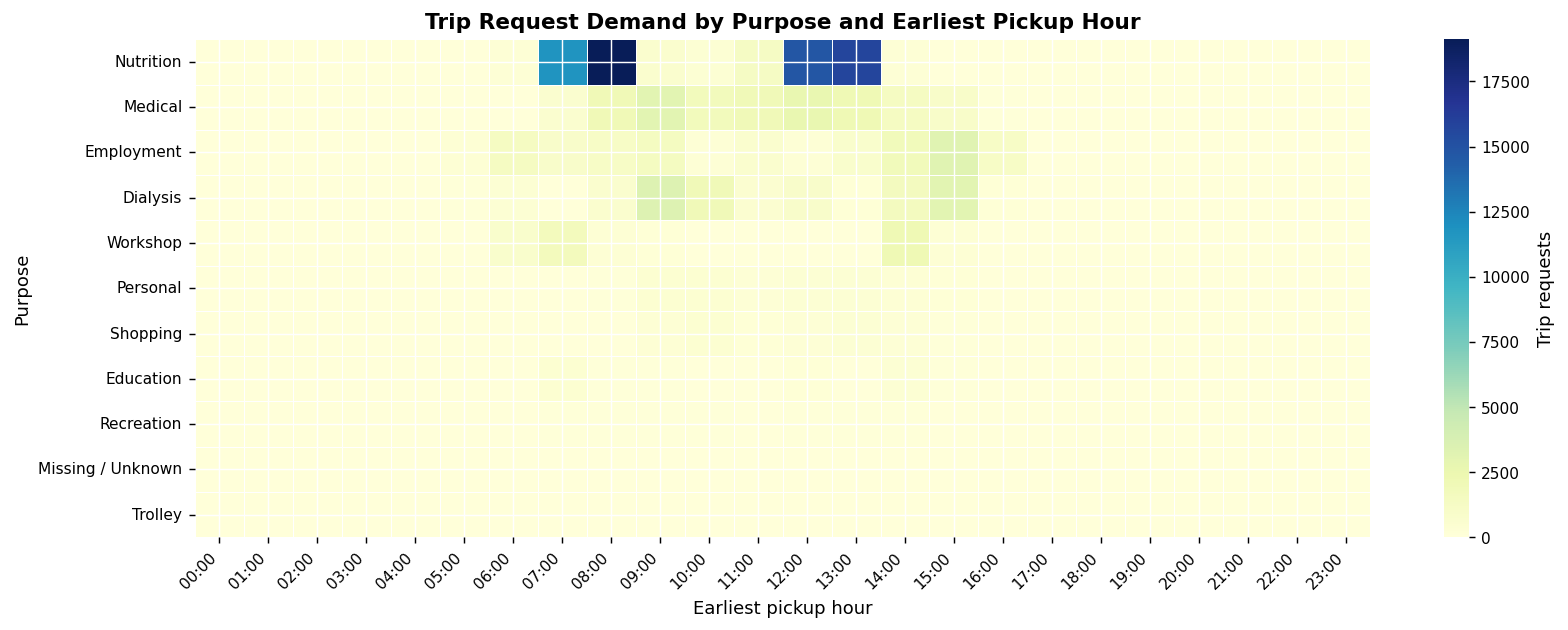

In [4]:
def hour_from_time(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if not s:
        return np.nan
    try:
        return int(s.split(':')[0])
    except Exception:
        dt = pd.to_datetime(s, errors='coerce')
        return np.nan if pd.isna(dt) else dt.hour


df_time_demand = df_raw.copy()
df_time_demand['Purpose'] = (
    df_time_demand['Purpose']
    .astype('string')
    .str.strip()
    .fillna('Missing / Unknown')
    .replace('', 'Missing / Unknown')
)
df_time_demand['pickup_hour'] = df_time_demand['Earliest Pick-up'].apply(hour_from_time)
df_time_demand = df_time_demand.dropna(subset=['Purpose', 'pickup_hour']).copy()
df_time_demand['pickup_hour'] = df_time_demand['pickup_hour'].astype(int)

purpose_hourly_demand = (
    df_time_demand
    .groupby(['Purpose', 'pickup_hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

purpose_hourly_demand = purpose_hourly_demand.loc[
    purpose_hourly_demand.sum(axis=1).sort_values(ascending=False).index
]

print('All valid trip requests by earliest pickup hour and purpose:')
display(purpose_hourly_demand.style.format('{:,.0f}'))

fig, ax = plt.subplots(figsize=(13, max(3.5, 0.45 * len(purpose_hourly_demand))))
sns.heatmap(
    purpose_hourly_demand,
    cmap='YlGnBu',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Trip requests'},
    ax=ax,
)
ax.set_title('Trip Request Demand by Purpose and Earliest Pickup Hour')
ax.set_xlabel('Earliest pickup hour')
ax.set_ylabel('Purpose')
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.tight_layout()


## 3. Redesigned demand-segment flexibility

The segment score is one interactive index. It does not calculate independent temporal, destination, and purpose scores, because those pieces are not independent in the demand-management problem.

For each demand segment:

```text
demand_segment = purpose + 1-mile origin grid zone + weekday
```

The time component uses `Earliest Pick-up` and 30-minute bins. Each bin is a half-open clock interval:

```text
07:00 bin = [07:00, 07:30)
07:30 bin = [07:30, 08:00)
14:00 bin = [14:00, 14:30)
14:30 bin = [14:30, 15:00)
```

So a trip at 14:17 is assigned to the 14:00 bin, while a trip at 14:30 is assigned to the 14:30 bin.

The code builds the observed joint distribution of:

```text
30-minute pickup time bin + destination grid zone
```

Then it calculates:

```text
interactive_diversity_index =
    entropy-derived effective number of observed time-destination pairs
    normalized by possible time-destination pairs in the same purpose-weekday context

density_weight =
    log-scaled trip density for the segment, capped at 100 trips

interactive_flexibility_index =
    interactive_diversity_index * density_weight
```

The multiplication means both conditions are required: a segment needs observed time-destination alternatives and enough density to support those alternatives. The time-only and destination-only distributions are still returned as diagnostics, but they are not treated as separate flexibility indices.

Reliability filters:

```text
min_segment_trips = minimum total trips required in a segment
min_segment_service_days = minimum distinct calendar service dates required in a segment
```

The current run uses `min_segment_trips=10` and `min_segment_service_days=3`. A segment must satisfy both filters to be treated as reliable and used in relationship tables and maps.

Peak-share metrics:

```text
time_peak_share = share of a segment's trips in its most common 30-minute pickup bin
mean_time_peak_share = average time_peak_share across segments in a flexibility band
```

The notebook draws one aggregate origin-grid map and separate weekday maps, where each grid cell is colored by the trip-weighted mean flexibility index across reliable demand segments. In the current maps, higher-flexibility cells concentrate around the main service area and differ by weekday, so the weekday maps are more useful for operational flattening than the aggregate map alone.


Demand-segment definition: Purpose + 1-mile origin grid zone + weekday
Rows with valid purpose/time/coordinate fields: 121,281
Segments: 4,016
Reliable segments: 1,643 (min 10 trips and 3 service days)
The flexibility index is multiplicative: interactive diversity * density weight. Density is capped at 100 trips.
Largest demand segments:


,Purpose,origin_zone,weekday,trips,service_days,interactive_flexibility_index,interactive_diversity_index,density_weight,active_time_bins,effective_time_bins,active_destination_zones,effective_destination_zones,active_time_destination_pairs,effective_time_destination_pairs,peak_time_label,time_peak_share,interaction_peak_share
2621,Nutrition,r43_c24,Wednesday,974,52,0.028,0.028,1.000,6,3.29,10,6.94,23,10.90,12:00,44.8%,29.0%
2618,Nutrition,r43_c24,Monday,848,52,0.034,0.034,1.000,6,3.15,9,6.81,21,9.95,12:00,42.7%,32.3%
2620,Nutrition,r43_c24,Tuesday,839,52,0.033,0.033,1.000,8,3.47,10,6.63,33,10.54,13:00,49.2%,40.2%
2569,Nutrition,r41_c22,Wednesday,813,47,0.031,0.031,1.000,7,3.64,5,3.36,27,11.99,11:00,41.3%,18.9%
2838,Nutrition,r52_c32,Friday,782,53,0.052,0.052,1.000,10,4.21,12,8.12,43,19.17,12:30,45.9%,11.8%
2448,Nutrition,r35_c25,Thursday,776,52,0.038,0.038,1.000,6,2.17,14,10.11,31,14.75,13:00,61.6%,17.7%
2619,Nutrition,r43_c24,Thursday,763,52,0.025,0.025,1.000,6,3.37,10,6.94,23,10.22,13:00,45.9%,38.0%
2839,Nutrition,r52_c32,Monday,762,52,0.062,0.062,1.000,8,3.68,12,8.46,25,17.23,12:30,47.6%,11.3%
2617,Nutrition,r43_c24,Friday,753,53,0.033,0.033,1.000,7,3.15,9,7.64,28,12.48,12:00,59.0%,21.4%
2842,Nutrition,r52_c32,Wednesday,745,52,0.045,0.045,1.000,8,3.87,13,8.14,29,16.87,12:30,47.2%,11.7%


Relationship between demand-segment flexibility bands and outcomes:


,flexibility_band,segments,trips,mean_interactive_flexibility_index,mean_interactive_diversity_index,mean_density_weight,mean_active_time_bins,mean_effective_time_bins,mean_active_destination_zones,mean_effective_destination_zones,mean_active_time_destination_pairs,mean_effective_time_destination_pairs,trip_weighted_completion_rate,trip_weighted_cancellation_rate,mean_time_peak_share
0,Q1,329,16498,0.000,0.001,0.800,2.0,1.30,1.2,1.07,2.1,1.32,61.1%,34.5%,92.9%
1,Q2,328,12132,0.002,0.003,0.720,3.8,2.80,2.0,1.59,4.4,3.21,55.2%,41.3%,62.2%
2,Q3,329,16068,0.004,0.005,0.766,4.8,3.66,2.4,1.95,6.0,4.60,51.8%,44.1%,52.2%
3,Q4,328,17089,0.007,0.010,0.788,5.6,4.18,3.1,2.42,8.0,6.12,49.0%,48.7%,49.6%
4,Q5,329,50795,0.028,0.033,0.839,6.4,4.39,6.1,4.34,16.0,11.42,54.4%,43.9%,47.5%


High-priority demand-management candidates:


...

Peak and alternative pickup-time bins within highest-priority candidates:


,candidate_rank,Purpose,origin_zone,weekday,pickup_time_bin_label,trips_in_time_bin,active_destination_zones,effective_destination_zones,share_within_segment,is_peak_time_bin,alternative_time_share,segment_trips,segment_peak_time_label,segment_time_peak_share,demand_management_priority
0,1,Workshop,r38_c21,Friday,14:00,226,8,5.95,97.4%,True,0.0%,232,14:00,97.4%,0.132
1,1,Workshop,r38_c21,Friday,15:00,4,4,4.00,1.7%,False,1.7%,232,14:00,97.4%,0.132
2,1,Workshop,r38_c21,Friday,09:00,1,1,1.00,0.4%,False,0.4%,232,14:00,97.4%,0.132
3,1,Workshop,r38_c21,Friday,12:30,1,1,1.00,0.4%,False,0.4%,232,14:00,97.4%,0.132
4,2,Workshop,r38_c21,Tuesday,14:00,415,15,9.56,98.8%,True,0.0%,420,14:00,98.8%,0.131
5,2,Workshop,r38_c21,Tuesday,14:30,3,3,3.00,0.7%,False,0.7%,420,14:00,98.8%,0.131
6,2,Workshop,r38_c21,Tuesday,08:30,2,2,2.00,0.5%,False,0.5%,420,14:00,98.8%,0.131
7,3,Workshop,r38_c21,Thursday,14:00,408,18,10.14,98.3%,True,0.0%,415,14:00,98.3%,0.118
8,3,Workshop,r38_c21,Thursday,14:30,3,3,3.00,0.7%,False,0.7%,415,14:00,98.3%,0.118
9,3,Workshop,r38_c21,Thursday,12:00,2,2,2.00,0.5%,False,0.5%,415,14:00,98.3%,0.118


Top observed time-destination pairs within highest-priority candidates:


,candidate_rank,Purpose,origin_zone,weekday,pickup_time_bin_label,destination_zone,trip_count,share_within_segment,segment_trips,demand_management_priority
0,1,Workshop,r38_c21,Friday,14:00,r27_c25,64,27.6%,232,0.132
1,1,Workshop,r38_c21,Friday,14:00,r31_c24,48,20.7%,232,0.132
2,1,Workshop,r38_c21,Friday,14:00,r34_c23,46,19.8%,232,0.132
3,1,Workshop,r38_c21,Friday,14:00,r40_c16,30,12.9%,232,0.132
4,1,Workshop,r38_c21,Friday,14:00,r27_c24,17,7.3%,232,0.132
5,1,Workshop,r38_c21,Friday,14:00,r43_c15,12,5.2%,232,0.132
6,1,Workshop,r38_c21,Friday,14:00,r24_c24,6,2.6%,232,0.132
7,1,Workshop,r38_c21,Friday,14:00,r37_c34,3,1.3%,232,0.132
8,2,Workshop,r38_c21,Tuesday,14:00,r37_c34,67,16.0%,420,0.131
9,2,Workshop,r38_c21,Tuesday,14:00,r27_c25,66,15.7%,420,0.131


Origin grid flexibility map saved to: demand_segment_origin_grid_flexibility_map.png


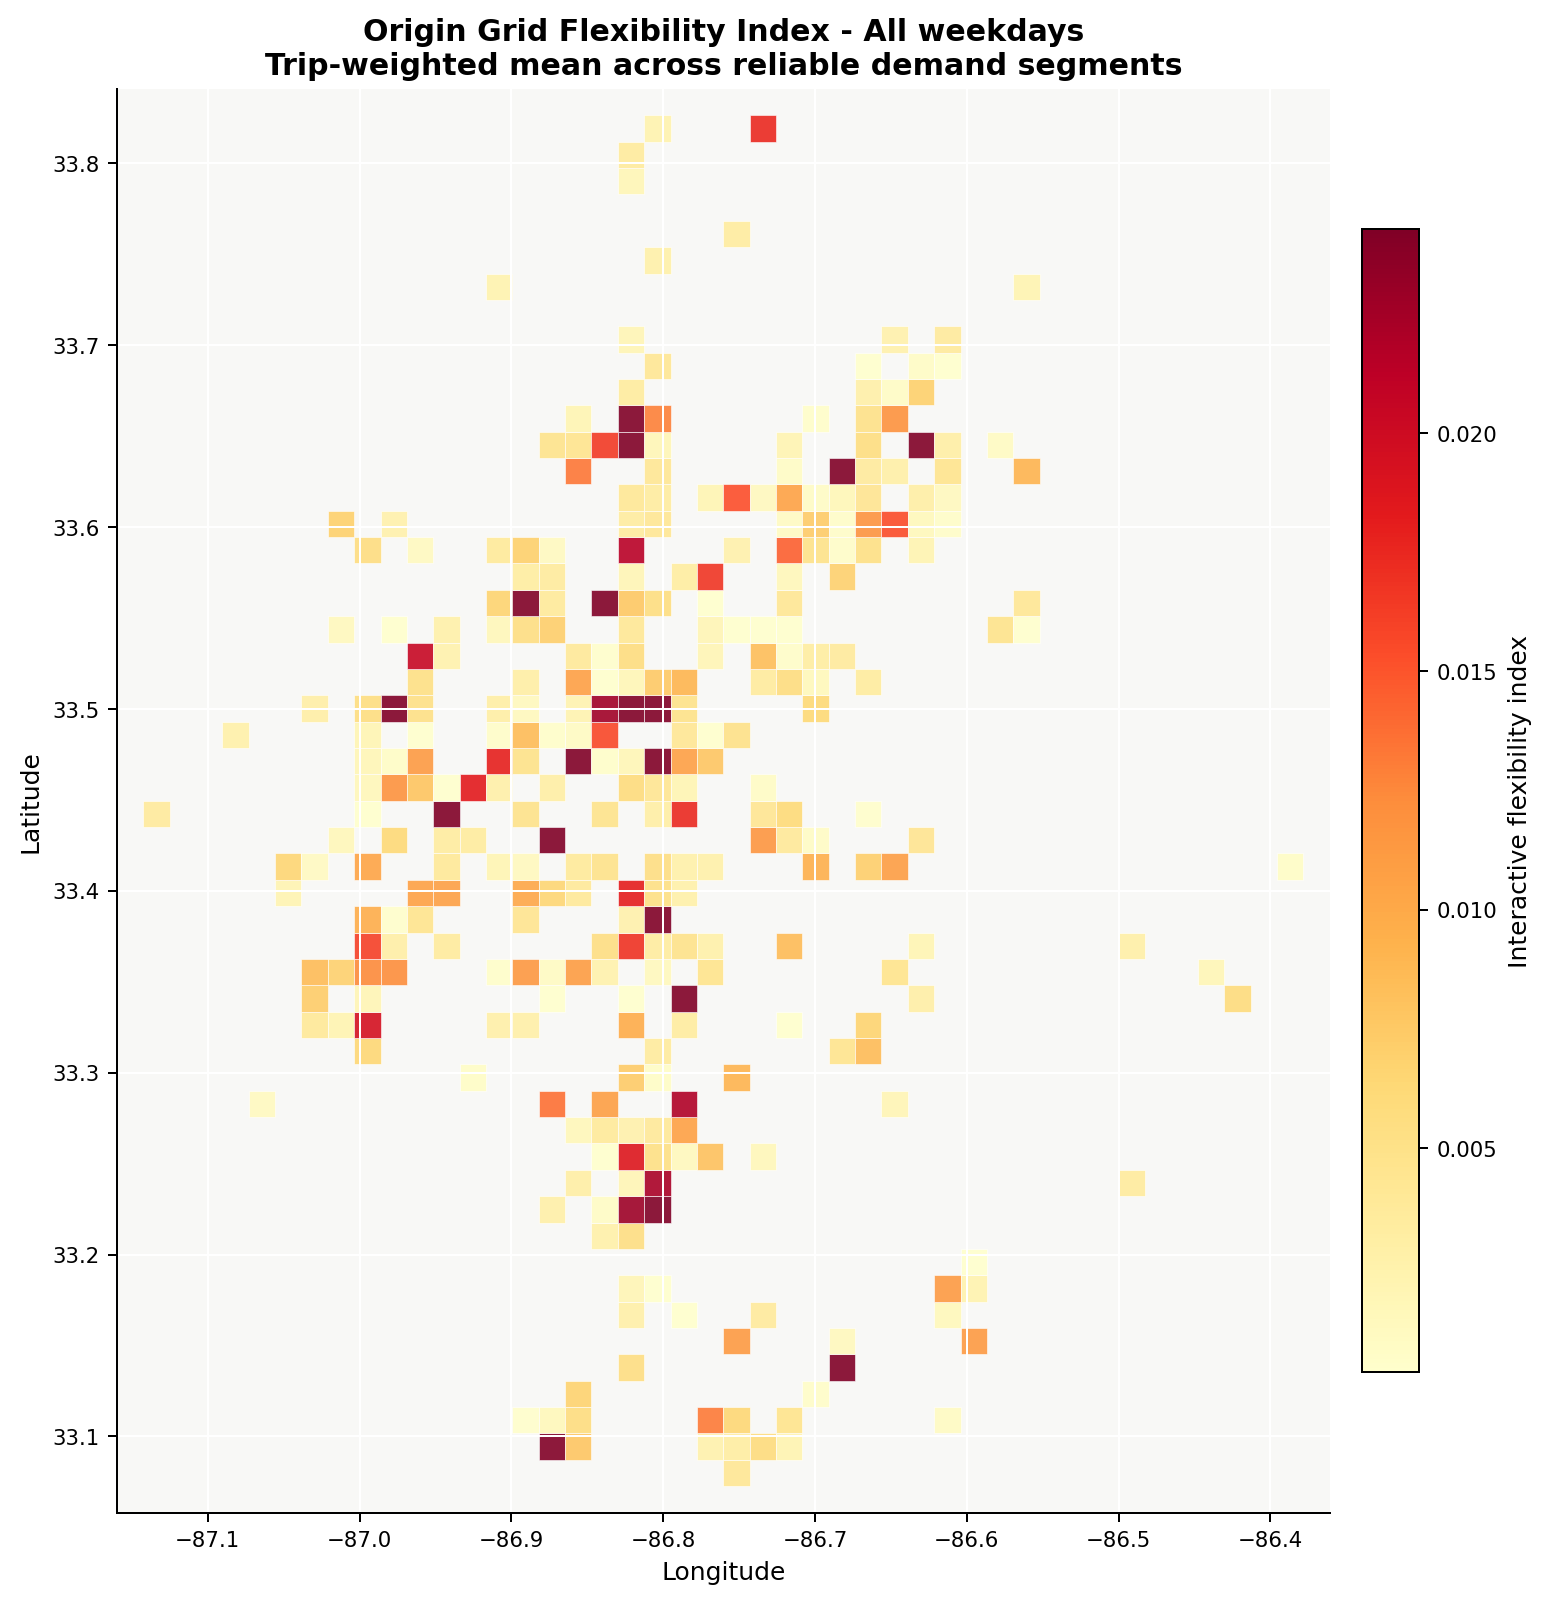

Monday origin grid flexibility map saved to: demand_segment_origin_grid_flexibility_map_monday.png


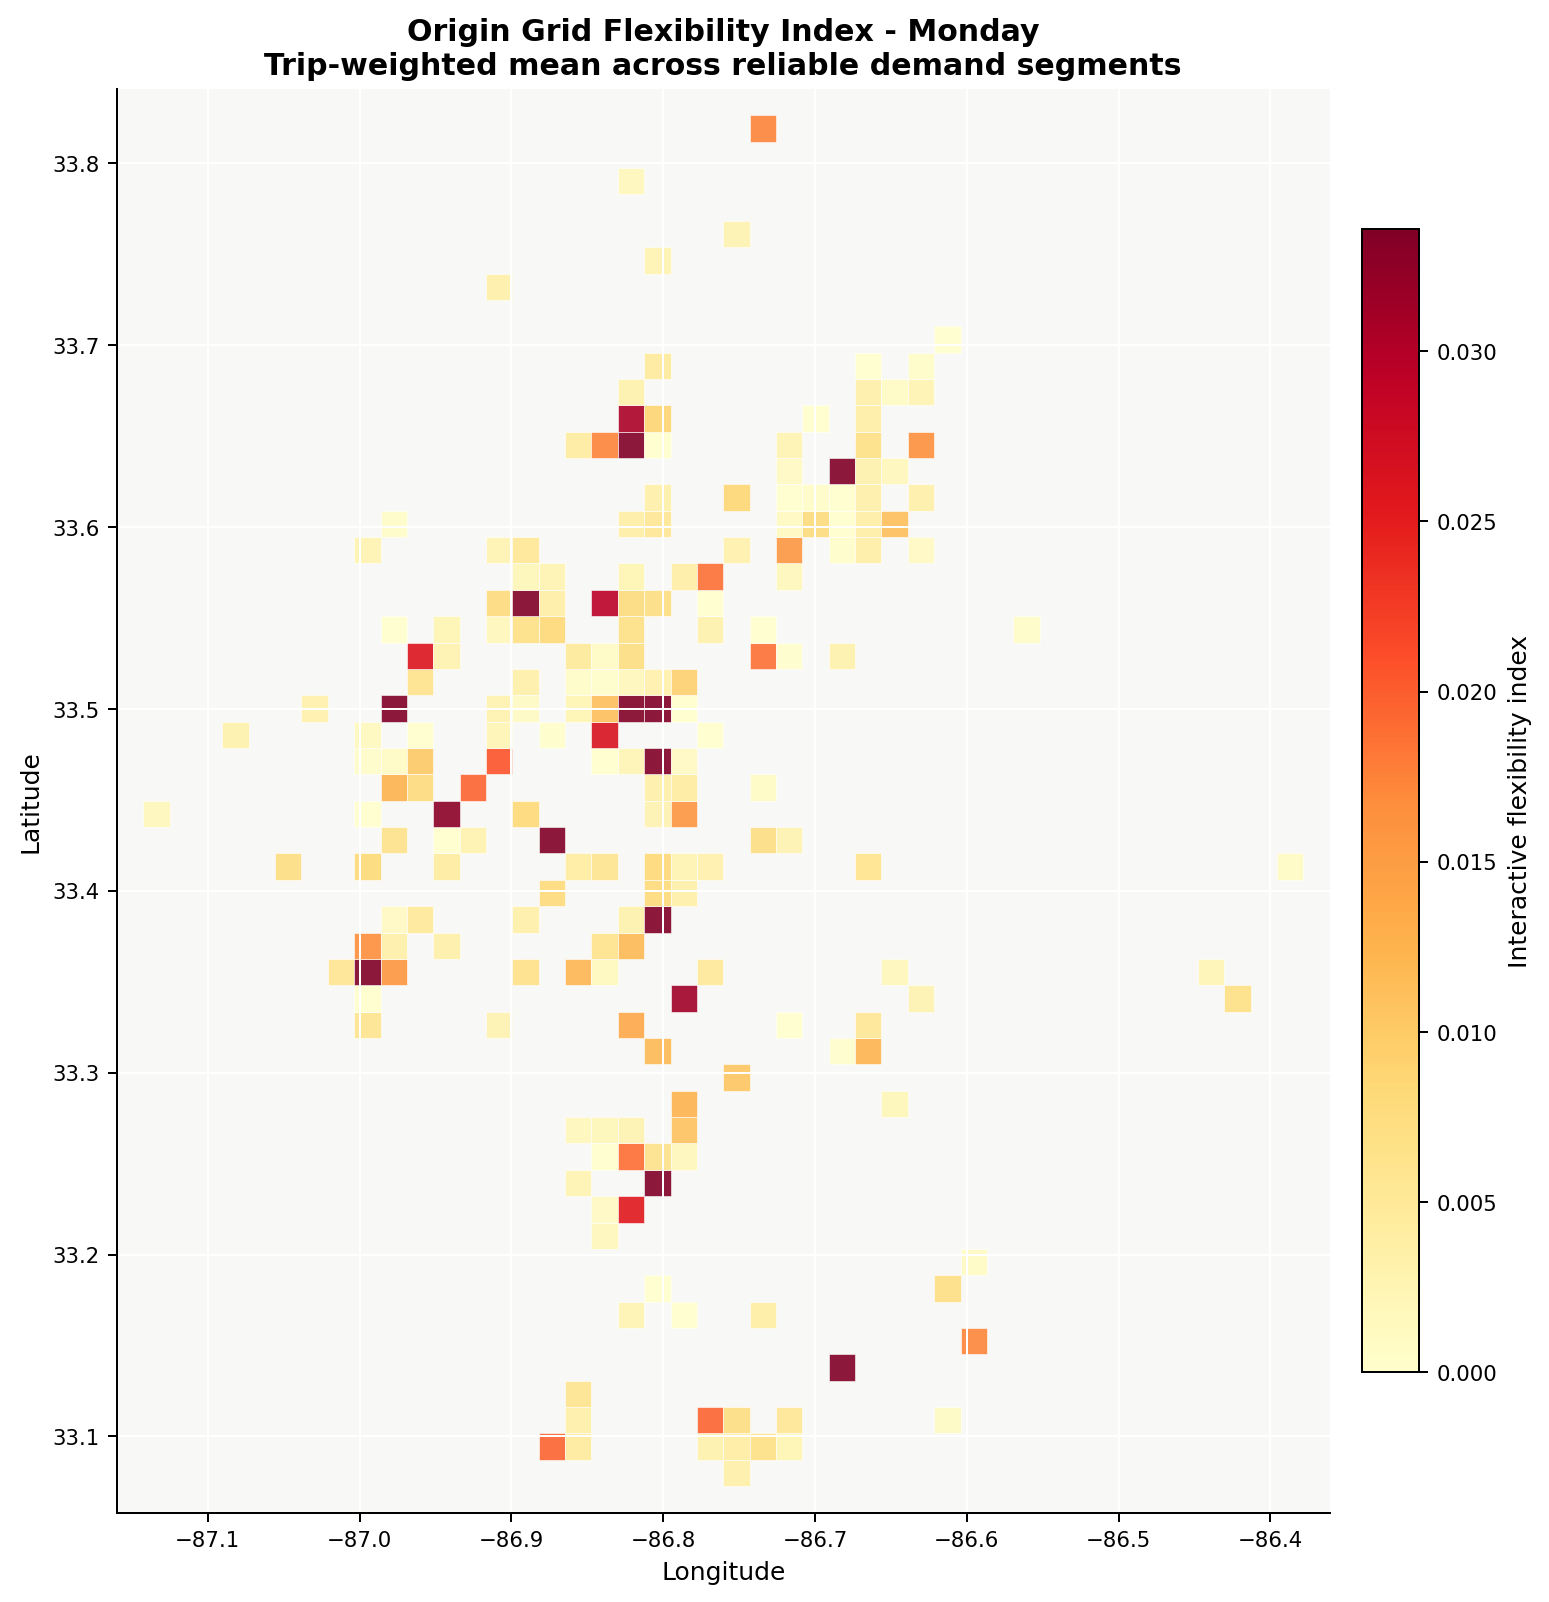

Tuesday origin grid flexibility map saved to: demand_segment_origin_grid_flexibility_map_tuesday.png


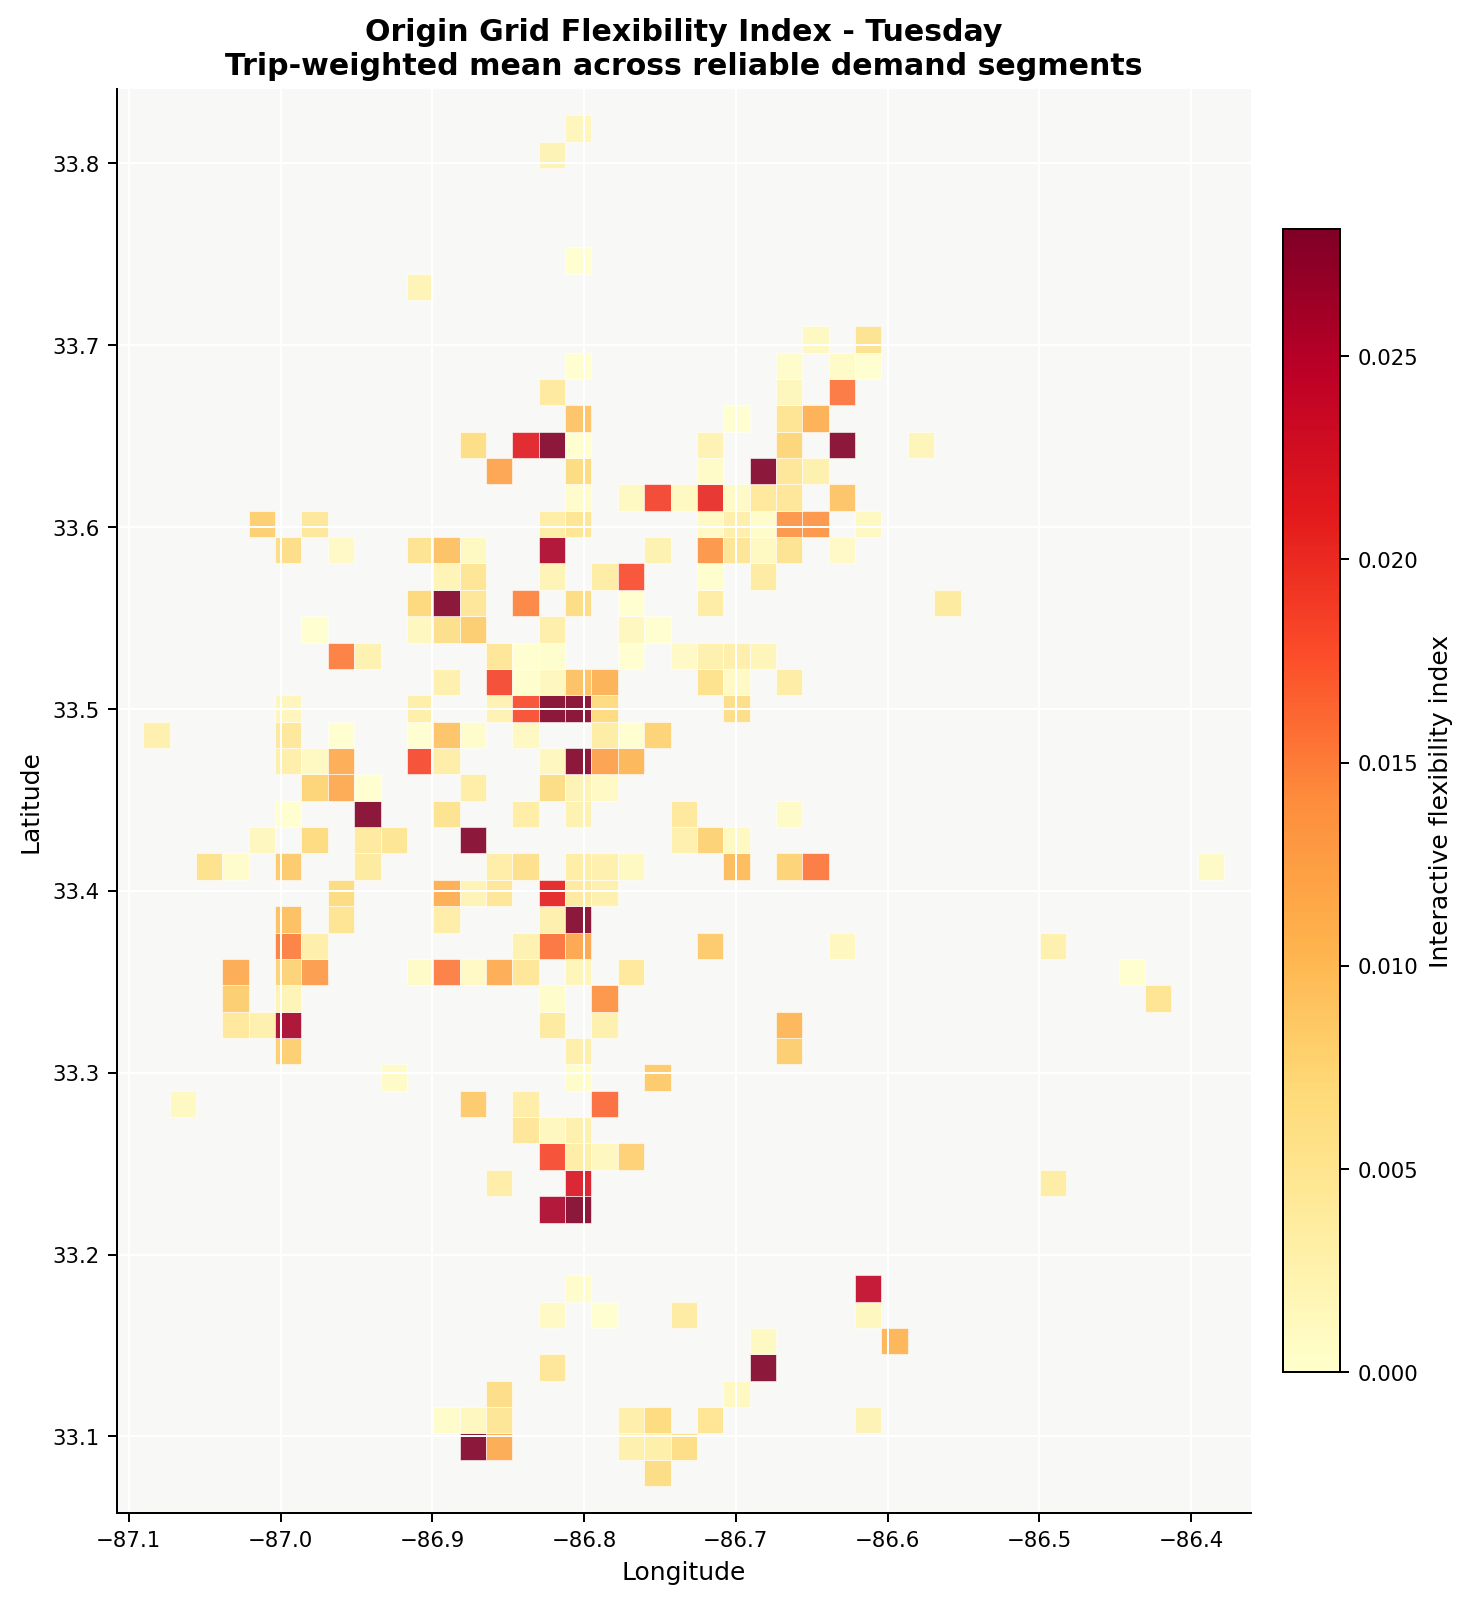

Wednesday origin grid flexibility map saved to: demand_segment_origin_grid_flexibility_map_wednesday.png


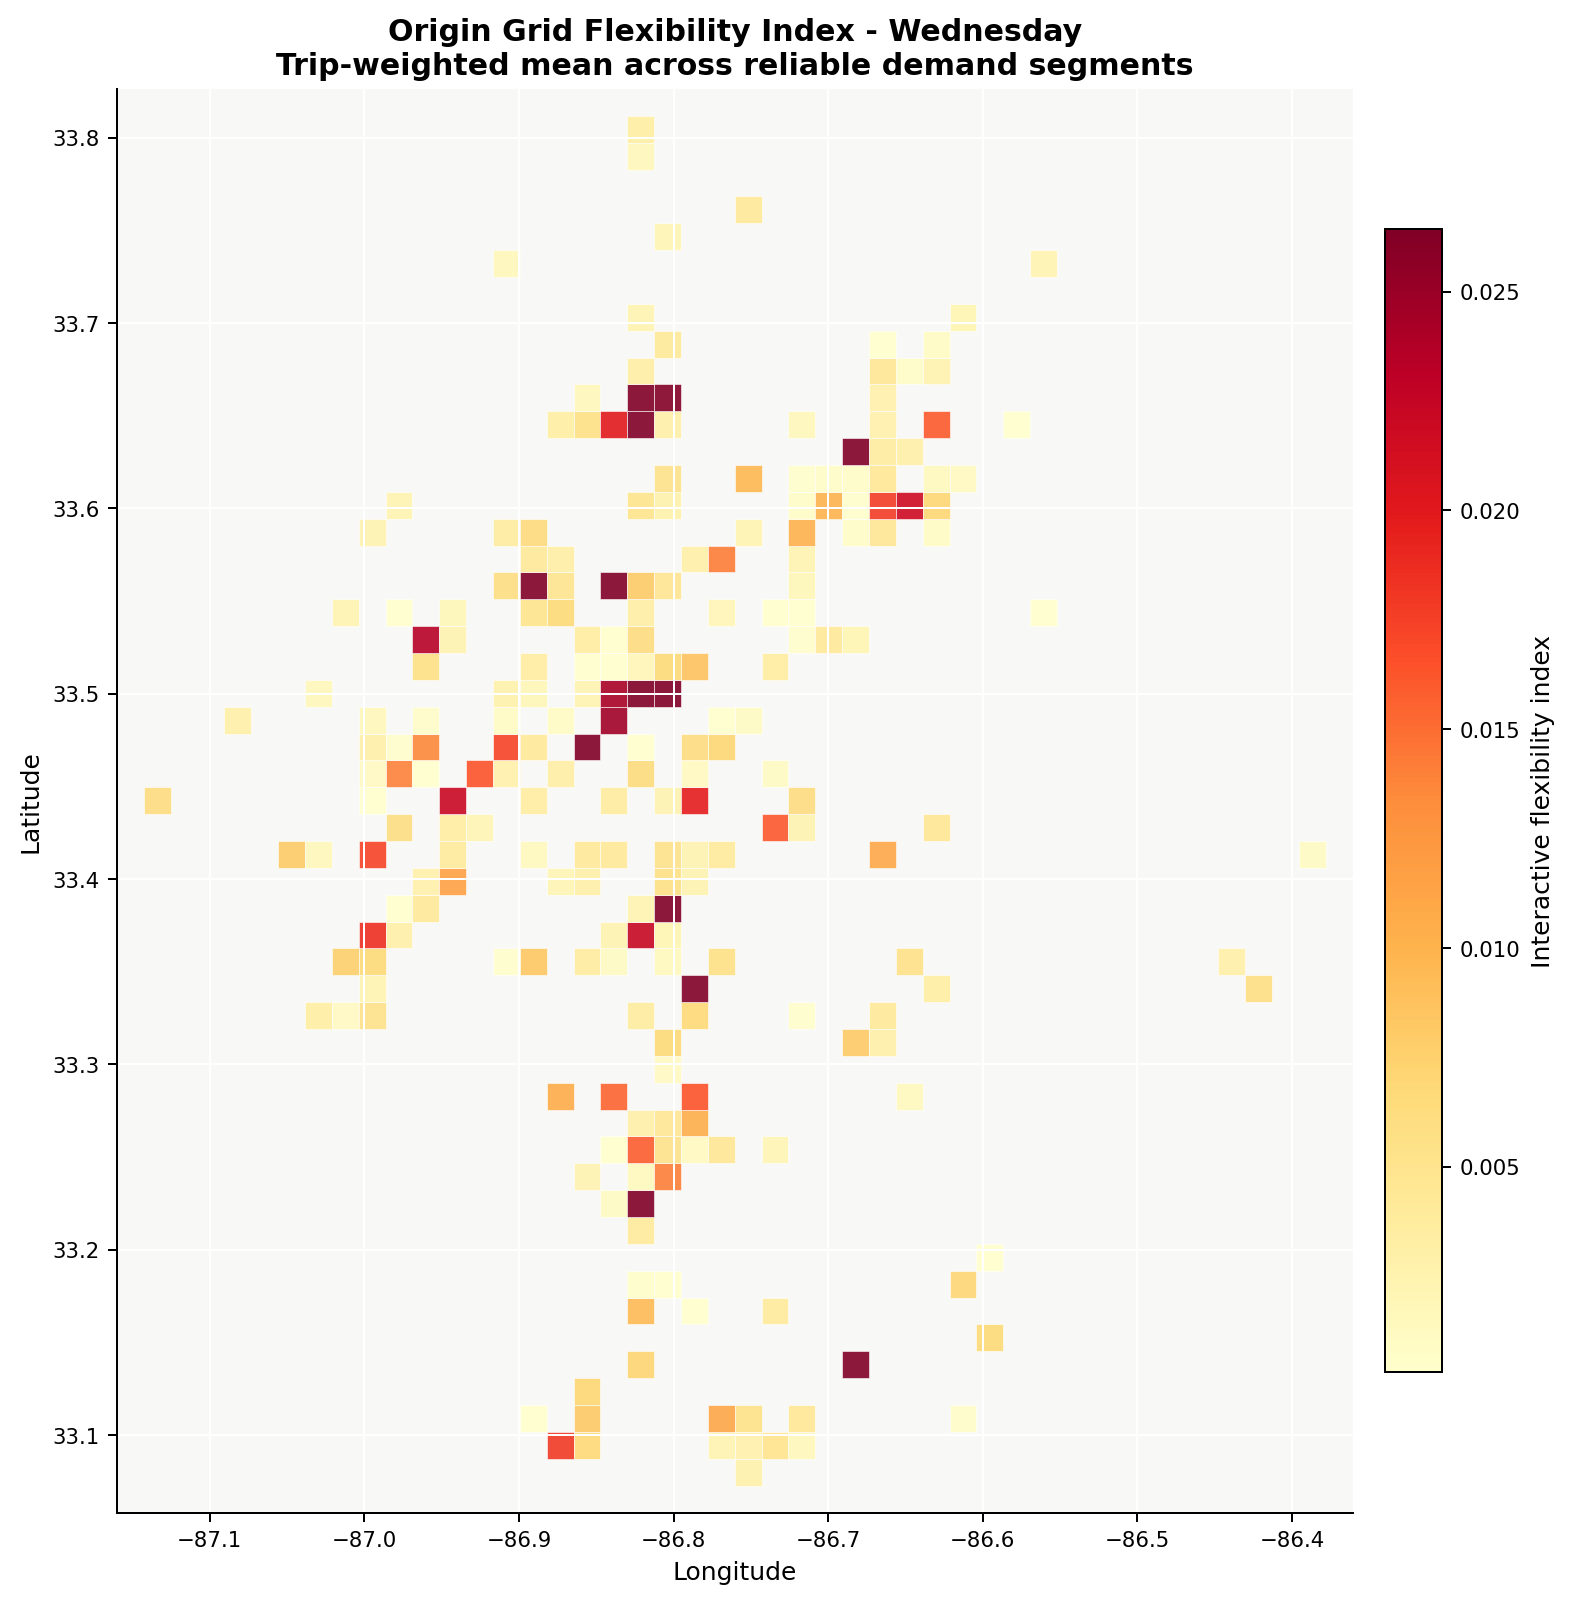

Thursday origin grid flexibility map saved to: demand_segment_origin_grid_flexibility_map_thursday.png


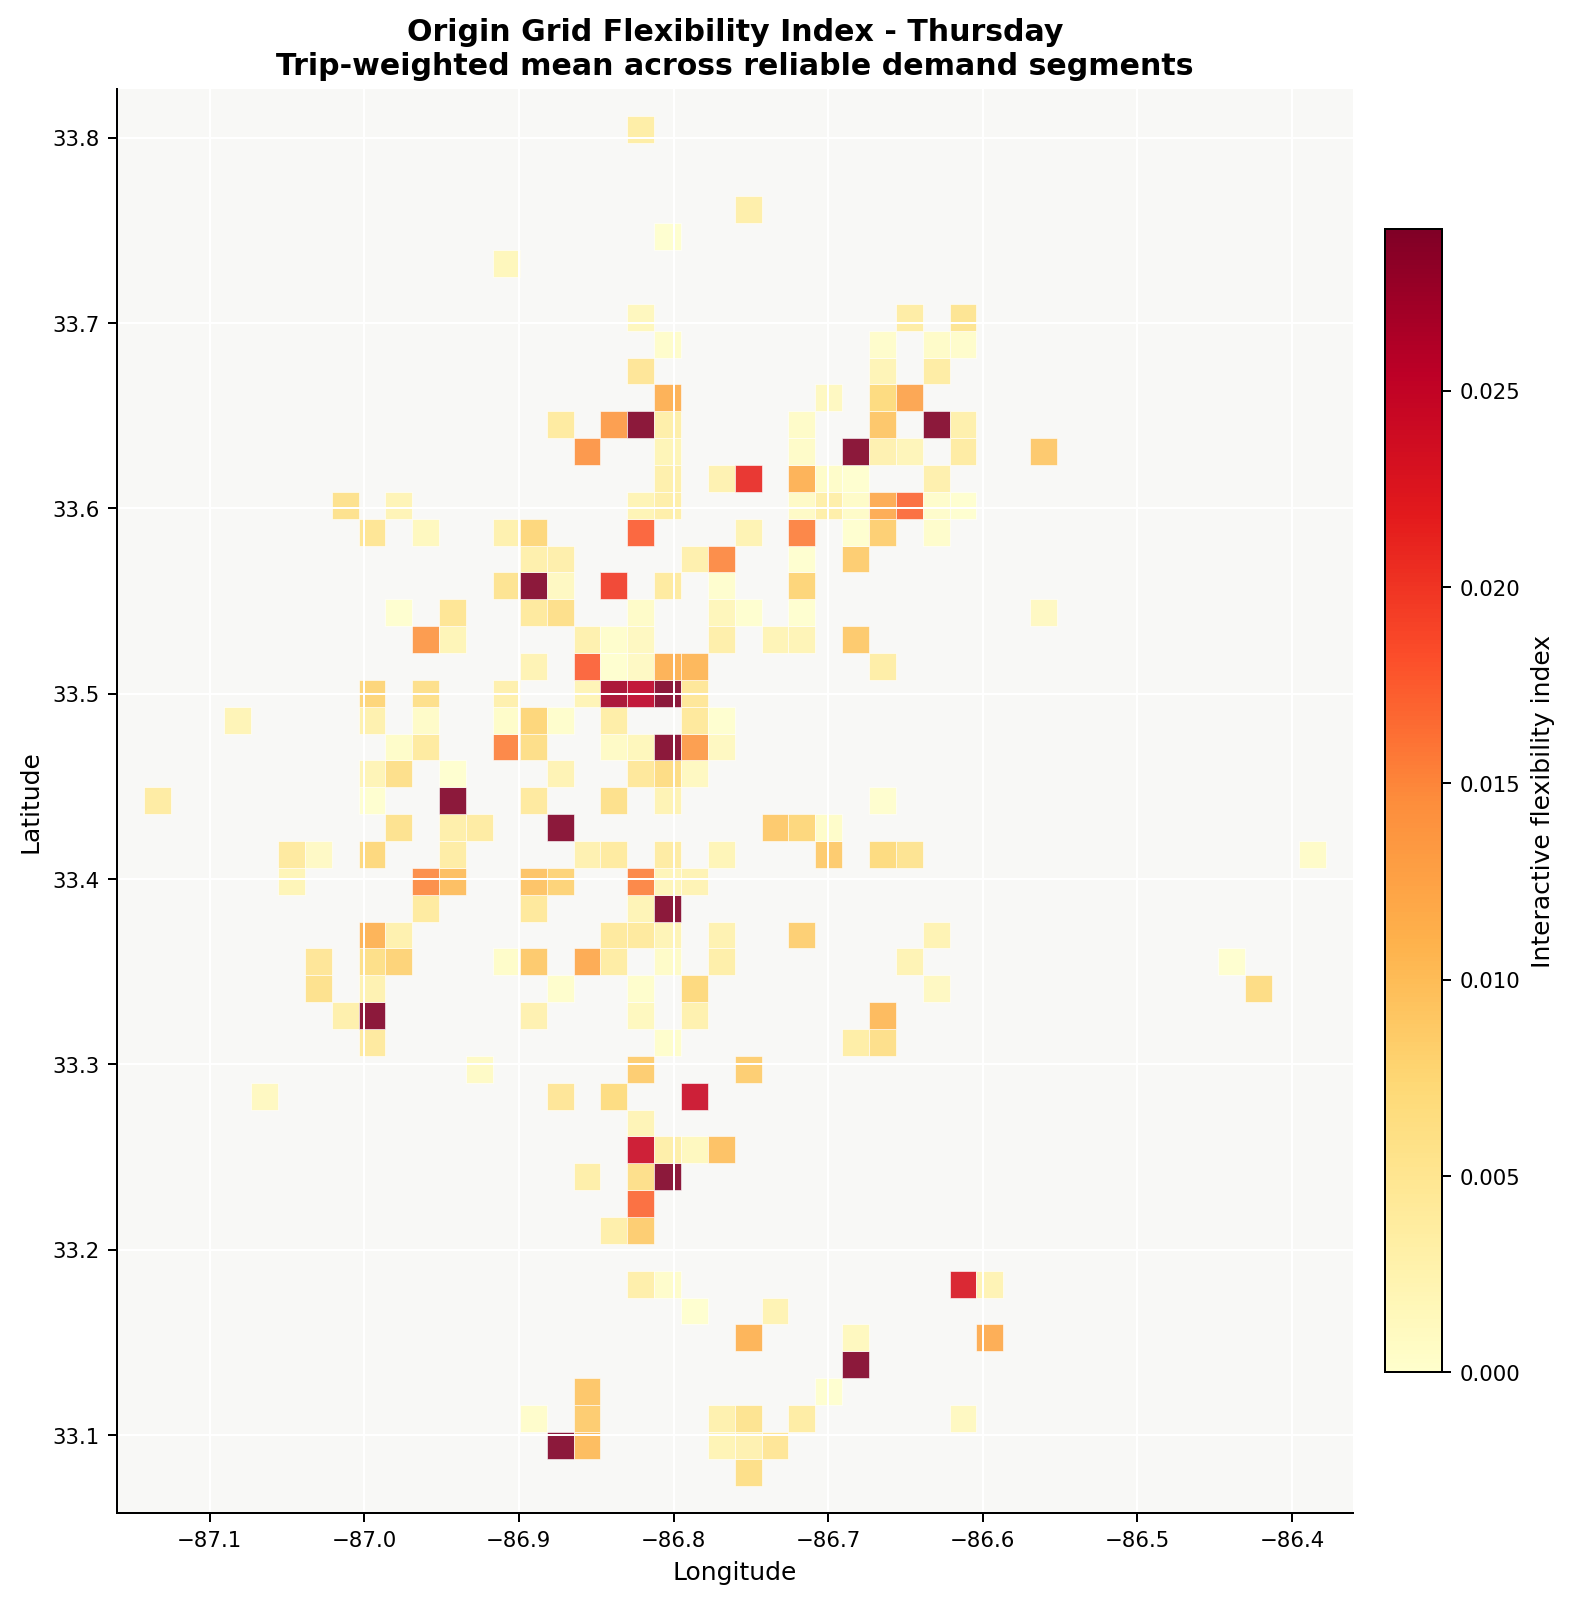

Friday origin grid flexibility map saved to: demand_segment_origin_grid_flexibility_map_friday.png


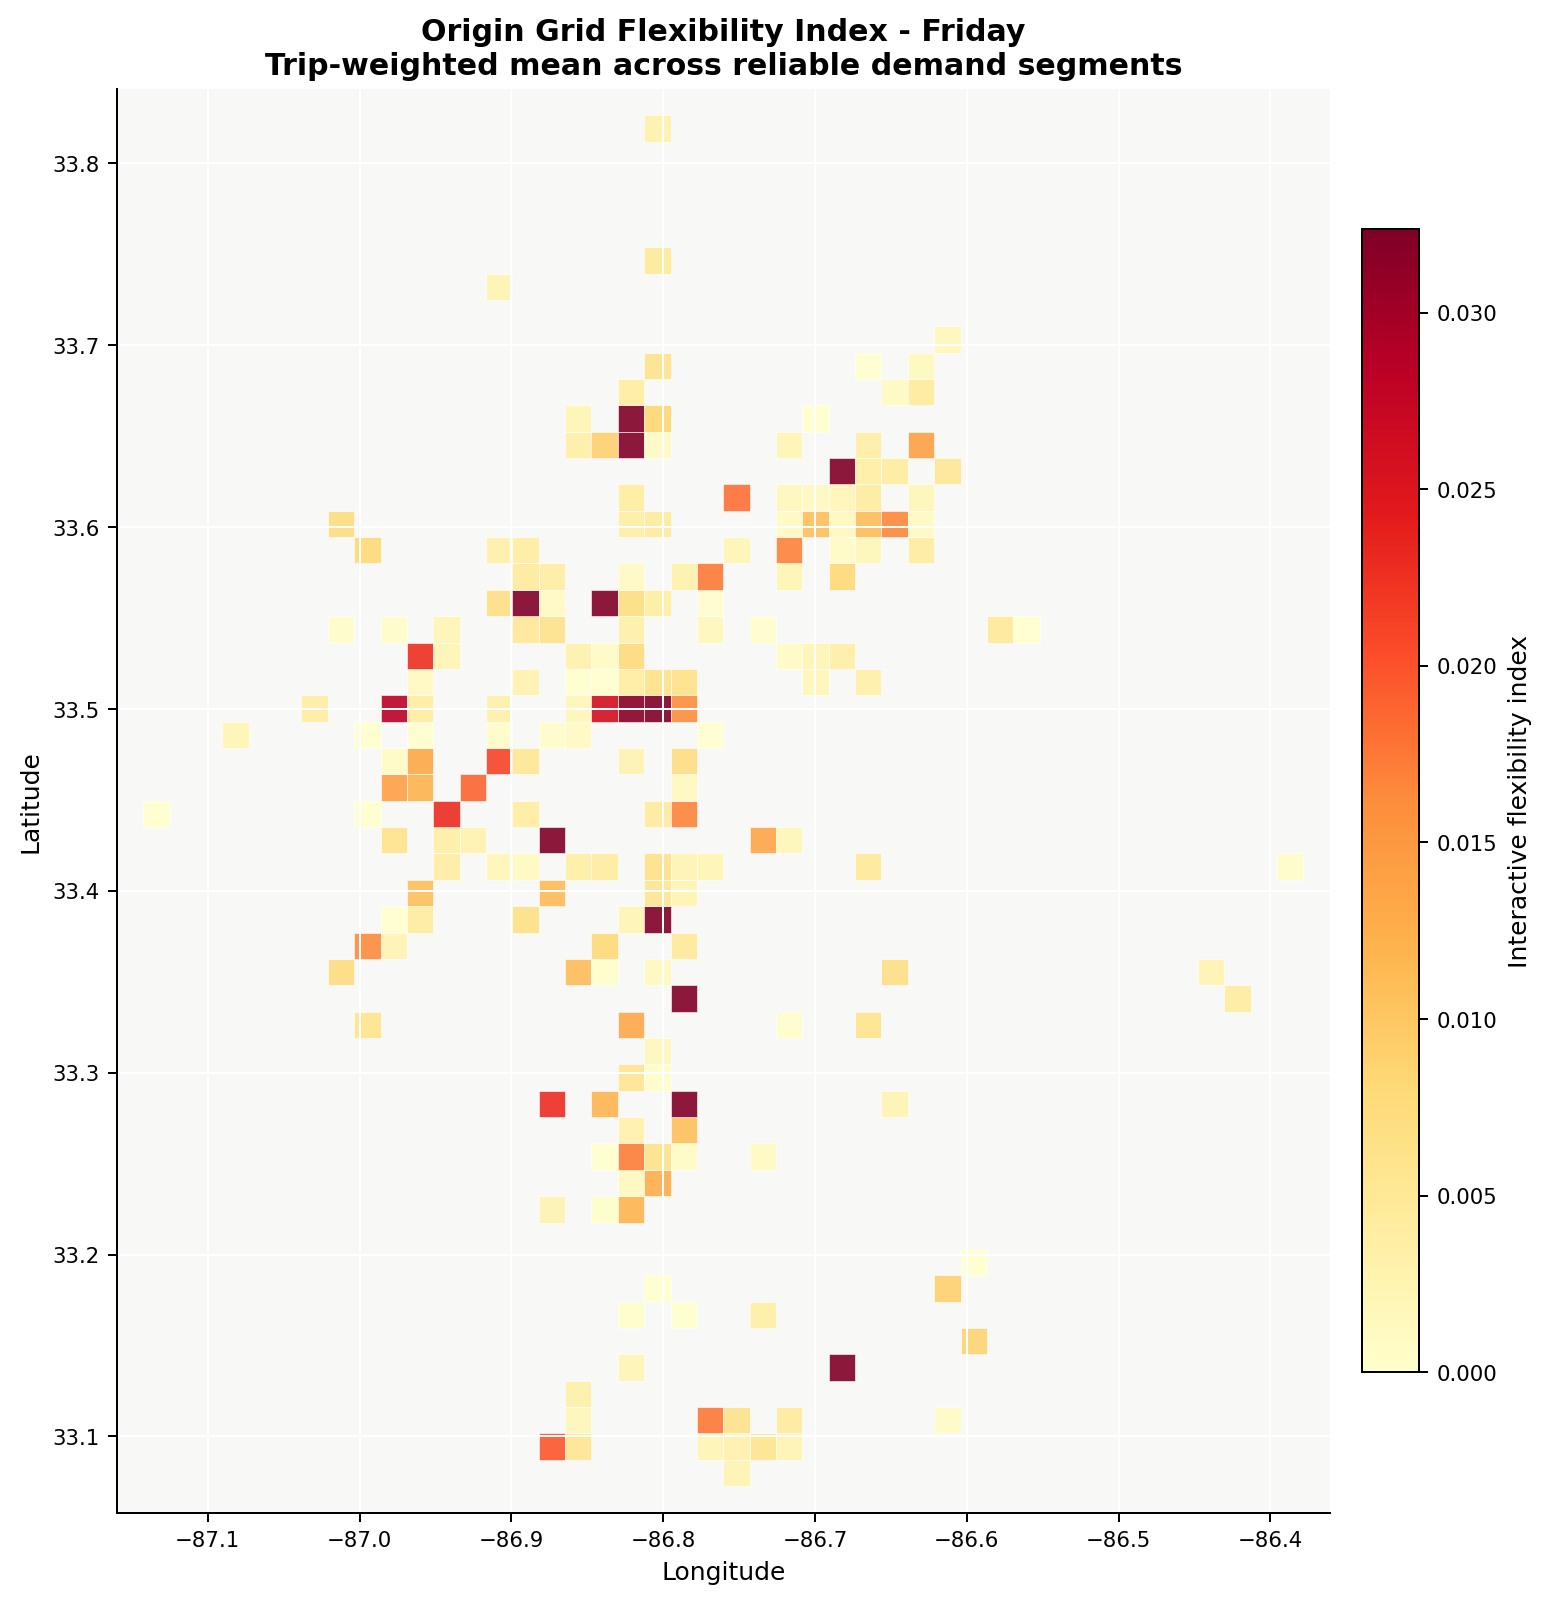

In [5]:
from demand_segment_flexibility import run_demand_segment_flexibility_analysis

segment_flexibility_results = run_demand_segment_flexibility_analysis(
    df_raw=df_raw,
    grid_miles=1.0,
    time_bin_minutes=30,
    min_segment_trips=10,
    min_segment_service_days=3,
    density_reference_trips=100,
    map_output_path='demand_segment_origin_grid_flexibility_map.png',
)


## 4. How to use the outputs

The main output table is:

```text
segment_flexibility_results['segment_summary']
```

The main index column is:

```text
interactive_flexibility_index
```

Its explanation columns are:

```text
interactive_diversity_index
density_weight
interaction_peak_share
```

Reliable-segment columns:

```text
trips = total trips in the demand segment
service_days = number of distinct calendar dates observed for the segment
meets_reliability_filter = trips >= min_segment_trips and service_days >= min_segment_service_days
```

Peak-share columns:

```text
time_peak_share = share of the segment's trips in the most common pickup-time bin
mean_time_peak_share = average time_peak_share inside a flexibility band
```

Useful diagnostic outputs are:

```text
segment_flexibility_results['relationship_by_band']
segment_flexibility_results['demand_management_candidates']
segment_flexibility_results['time_distribution']
segment_flexibility_results['destination_distribution']
segment_flexibility_results['interaction_distribution']
segment_flexibility_results['top_candidate_time_shift_options']
segment_flexibility_results['top_candidate_alternatives']
segment_flexibility_results['origin_grid_map_path']
segment_flexibility_results['origin_grid_map_paths']
```

`top_candidate_time_shift_options` is the main demand-management table for flattening. It shows the peak pickup-time bin and observed non-peak pickup-time bins for the highest-priority candidate segments. It focuses on whether peak trips may be moved into another time; completion and cancellation rates are not used in this flattening table.

`origin_grid_map_path` is the aggregate map. `origin_grid_map_paths['weekday']` stores the separate Monday-Sunday maps when reliable segments exist for those days.

The candidate table should be interpreted as a planning screen: high priority means the segment has observed interactive flexibility and peak concentration. It does not mean trips should be automatically shifted without rider consent or operating-policy checks.
